In [ ]:
!pip install torch torchvision opencv-python matplotlib --quiet

Saving istockphoto-866119234-1024x1024.jpg to istockphoto-866119234-1024x1024.jpg


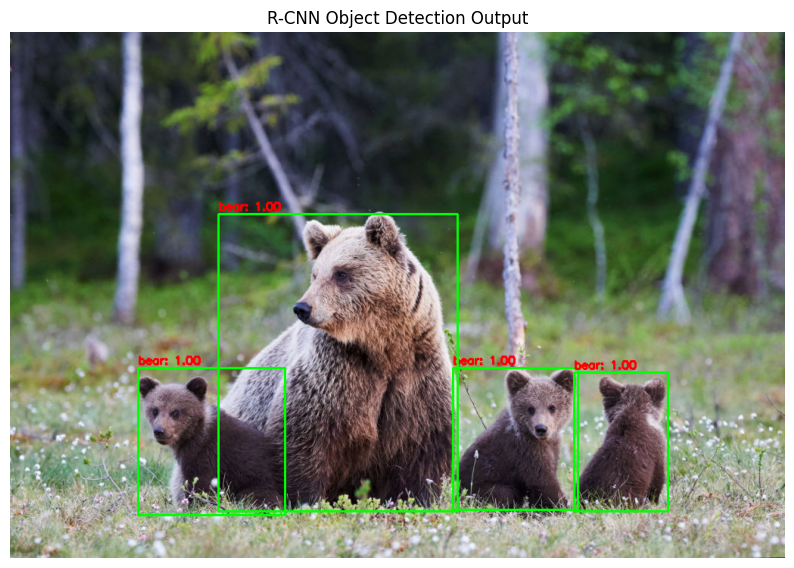

In [ ]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import torchvision.transforms as T
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
model.to(device)
model.eval()


uploaded = files.upload()
image_path = list(uploaded.keys())[0]


image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


transform = T.Compose([T.ToTensor()])
image_tensor = transform(image_rgb).to(device)


with torch.no_grad():
    outputs = model([image_tensor])


boxes = outputs[0]['boxes'].cpu().numpy()
scores = outputs[0]['scores'].cpu().numpy()
labels = outputs[0]['labels'].cpu().numpy()


threshold = 0.5
classes = weights.meta["categories"]


for box, score, label in zip(boxes, scores, labels):
    if score > threshold:
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        text = f"{classes[label]}: {score:.2f}"
        cv2.putText(image_rgb, text, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)


plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("R-CNN Object Detection Output")
plt.show()
